# Лабораторна робота № 3 — Порівняння метричних методів і машин опорних векторів

**Варіант 5.** Набір даних **Wine Dataset**, той самий, що в [ЛР № 2](../../lab02/),
зведений до бінарної задачі (сорт 1 проти решти).

**Мета роботи.** Дослідити принципи класифікації на основі відстані та
роздільної межі; експериментально визначити вплив метрики, масштабування,
кількості сусідів, типу ядра та гіперпараметрів SVM на якість і обчислювальні
характеристики моделі.

Повний EDA не повторюється — використовуються рішення, зафіксовані в ЛР № 2:
вибір позитивного класу (сорт 1, обґрунтований відстанями між центрами класів
і крос-валідацією за всіма трьома варіантами зведення), препроцесинг,
train/test split.


In [1]:
import time
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_wine, make_moons
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score, make_scorer,
)

RANDOM_STATE = 42
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

f1_scorer = make_scorer(f1_score, zero_division=0)


## 1. Постановка експериментальної задачі

**Прикладна мета** — та сама, що в ЛР № 2: верифікація сорту вина за хімічним
аналізом (контроль автентичності). Позитивний клас — сорт 1 (найменш хімічно
відокремлений, обґрунтування — в ЛР № 2, розділ 2).

**Важливі помилки.** Як і в ЛР № 2, із позиції контролю якості критичніша
помилка — **False Positive** (фальсифікат проходить перевірку).

**Основна метрика порівняння — F1** (позитивний клас), додатково Accuracy.

### Перевірювані гіпотези

| № | Гіпотеза | Перевірка | Критерій підтвердження |
|---|---|---|---|
| Г1 | Масштабування суттєво впливає на kNN і RBF SVM через різні діапазони ознак (`proline` розмах 1402, `nonflavanoid_phenols` — 0.53), але значно менше на linear SVM | 3 моделі × {без scaler, StandardScaler, MinMaxScaler}, фіксовані параметри | приріст F1 після масштабування для kNN і RBF SVM істотно більший, ніж для linear SVM |
| Г2 | Евклідова метрика (`p=2`) з голосуванням за відстанню дає кращий CV F1, ніж `p=1`/рівномірне голосування | `GridSearchCV` по `k, p, weights` | найкраща конфігурація має `p=2, weights="distance"` |
| Г3 | RBF SVM перевершує linear SVM, бо межа між класами нелінійна в просторі 13 хімічних ознак | окремий `GridSearchCV` для linear і RBF SVM за тими самими folds | CV F1 RBF SVM істотно (більше розкиду між фолдами) вищий за linear SVM |

**Інженерні критерії** (для розділу 13): затримка прогнозування, обсяг памʼяті
(розмір серіалізованої моделі, кількість збережених обʼєктів/опорних векторів),
пояснюваність рішення.


## 2. Планування експерименту (протокол)

| Компонент | Значення |
|---|---|
| Train/test split | 80/20, стратифікація, `random_state=42` — той самий, що в ЛР № 2 |
| Схема CV | `StratifiedKFold(5, shuffle=True, random_state=42)` |
| Основна метрика | F1 (позитивний клас); додатково Accuracy |
| Кандидатні моделі | NearestCentroid, kNN, Linear SVM, RBF SVM |
| Способи масштабування | без scaler, StandardScaler, MinMaxScaler |
| Сітка kNN | `k ∈ {1,3,5,7,11,15}`, `p ∈ {1,2}`, `weights ∈ {uniform, distance}` → 24 конфігурації |
| Сітка linear SVM | `C ∈ {0.01, 0.1, 1, 10, 100}` → 5 конфігурацій |
| Сітка RBF SVM | `C ∈ {0.1,1,10,100}`, `gamma ∈ {scale, 0.001, 0.01, 0.1, 1}` → 20 конфігурацій |
| Правило вибору фінальної моделі | найбільший CV F1; за різниці в межах розкиду між фолдами — інженерні критерії (розділ 9) |
| Момент відкриття test set | один раз, після фіксації фінальної моделі |


## 3. Контрольний геометричний експеримент (make_moons)

Мета — розділити дві різні причини помилок: **спотворену геометрію** (масштаб)
і **недостатню форму межі** (лінійна модель на нелінійних даних). Друга ознака
штучно збільшується у 18 разів — сама розстановка класів не змінюється.


In [2]:
X_moons, y_moons = make_moons(n_samples=520, noise=0.22, random_state=RANDOM_STATE)
X_moons_distorted = X_moons.copy()
X_moons_distorted[:, 1] *= 18.0

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons_distorted, y_moons, test_size=0.28, stratify=y_moons, random_state=RANDOM_STATE
)
print(Xm_train.shape, Xm_test.shape)


(374, 2) (146, 2)


In [3]:
def moons_pipeline(estimator, scale):
    step = StandardScaler() if scale else "passthrough"
    return Pipeline([("scale", step), ("model", estimator)])

moons_models = {
    "kNN (k=9)": KNeighborsClassifier(n_neighbors=9),
    "Linear SVM": SVC(kernel="linear", C=1),
    "RBF SVM": SVC(kernel="rbf", C=10, gamma="scale"),
}

moons_results = {}
for name, est in moons_models.items():
    for scale in [False, True]:
        pipe = moons_pipeline(est, scale).fit(Xm_train, ym_train)
        f1 = f1_score(ym_test, pipe.predict(Xm_test))
        moons_results[(name, scale)] = (pipe, f1)
        print(f"{name:12s} scale={scale!s:5s} F1={f1:.3f}")


kNN (k=9)    scale=False F1=0.857
kNN (k=9)    scale=True  F1=0.952
Linear SVM   scale=False F1=0.847
Linear SVM   scale=True  F1=0.847
RBF SVM      scale=False F1=0.821
RBF SVM      scale=True  F1=0.965


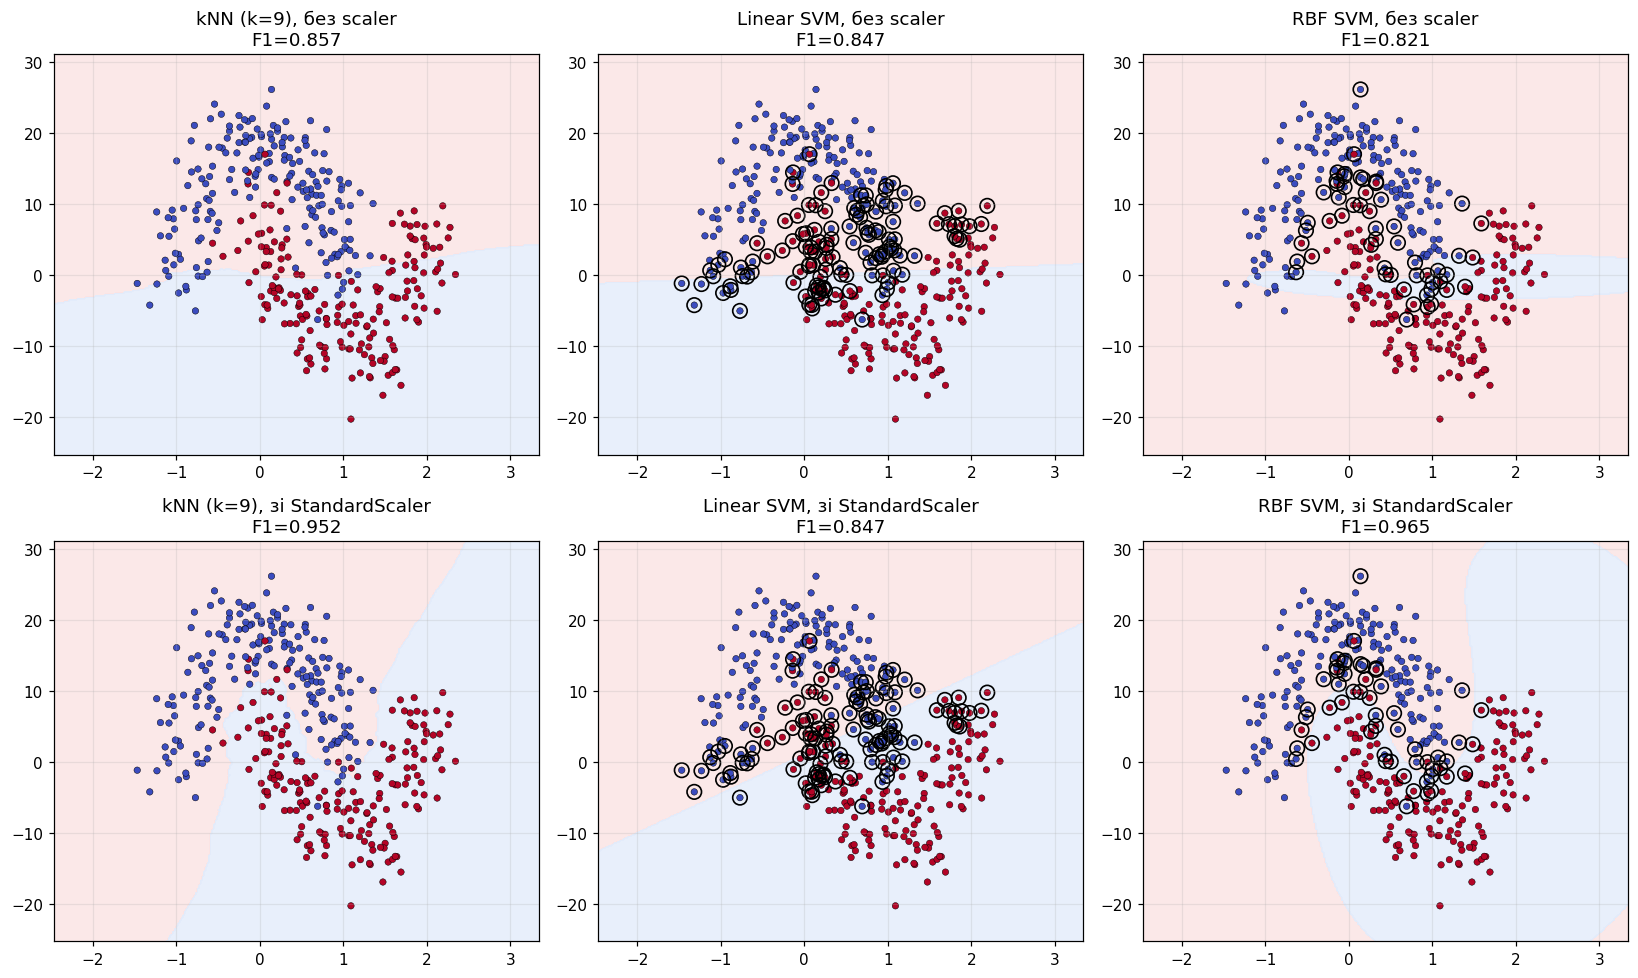

In [4]:
xx, yy = np.meshgrid(
    np.linspace(Xm_train[:, 0].min() - 1, Xm_train[:, 0].max() + 1, 300),
    np.linspace(Xm_train[:, 1].min() - 5, Xm_train[:, 1].max() + 5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
cmap_bg = ListedColormap(["#fbe3e3", "#e3ecfb"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, (name, est) in enumerate(moons_models.items()):
    for row, scale in enumerate([False, True]):
        ax = axes[row, col]
        pipe, f1 = moons_results[(name, scale)]
        Z = pipe.predict(grid).reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
        ax.scatter(Xm_train[:, 0], Xm_train[:, 1], c=ym_train, cmap="coolwarm",
                   edgecolor="black", linewidth=0.3, s=18)
        if hasattr(pipe.named_steps["model"], "support_"):
            sv_idx = pipe.named_steps["model"].support_
            ax.scatter(Xm_train[sv_idx, 0], Xm_train[sv_idx, 1], facecolors="none",
                       edgecolors="black", s=90, linewidth=1.1, label="опорні вектори")
        ax.set_title(f"{name}, {'зі StandardScaler' if scale else 'без scaler'}\nF1={f1:.3f}")
        if row == 0:
            ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIG / "01_moons_decision_boundaries.png")
plt.show()


**Без масштабування** kNN і RBF SVM спотворені розтягнутою віссю $x_2$ — межа
рішення витягується вздовж домінантної за масштабом координати. **Після
StandardScaler** обидві моделі відновлюють змістовну форму місяцеподібних
класів. **Linear SVM** не отримує суттєвого покращення від масштабування — її
головне обмеження це лінійна форма межі, а не масштаб координат; лінія просто
не може огорнути нелінійну структуру `make_moons` незалежно від масштабування.

Це розділяє дві причини помилок: спотворену геометрію (лікується scaler) і
недостатню форму моделі (лікується лише зміною сімейства моделі, напр. ядра).


## 4. Підготовка індивідуальних даних (Wine, бінарна задача)

Перевіряю, що властивості даних, зафіксовані в ЛР № 2, не змінилися.


In [5]:
wine = load_wine(as_frame=True)
X_wine = wine.frame.drop(columns="target")
y_wine = (wine.frame["target"] == 1).astype(int)  # той самий позитивний клас, що в ЛР №2

print(f"shape: {X_wine.shape}, пропусків: {X_wine.isna().sum().sum()}, "
      f"P(y=1)={y_wine.mean():.3f} (має бути 0.399, як у ЛР №2)")

X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"|D_train|={len(X_train)} (позитивних {y_train.sum()}), "
      f"|D_test|={len(X_test)} (позитивних {y_test.sum()})")


shape: (178, 13), пропусків: 0, P(y=1)=0.399 (має бути 0.399, як у ЛР №2)
|D_train|=142 (позитивних 57), |D_test|=36 (позитивних 14)


In [6]:
feature_ranges = (X_train.max() - X_train.min()).sort_values(ascending=False)
print("Розмах ознак (max-min) на train — обґрунтування потреби в масштабуванні:")
print(feature_ranges.round(3).to_string())


Розмах ознак (max-min) на train — обґрунтування потреби в масштабуванні:
proline                         1402.00
magnesium                         81.00
alcalinity_of_ash                 19.40
color_intensity                   10.47
malic_acid                         4.91
flavanoids                         4.74
alcohol                            3.80
proanthocyanins                    3.17
total_phenols                      2.87
od280/od315_of_diluted_wines       2.73
ash                                1.87
hue                                1.23
nonflavanoid_phenols               0.53


Усі 13 ознак числові, категоріальних немає — кодування не потрібне. Розмах
`proline` (1402) у ~2600 разів більший за розмах `nonflavanoid_phenols` (0.53).
Без масштабування відстань між обʼєктами визначатиметься майже виключно
одною ознакою — це і перевіряється далі як гіпотеза Г1, а не декларується.


## 5. Дослідження гіпотези про масштабування (Г1)

Три моделі з **фіксованими** параметрами (щоб зміна метрики відображала лише
вплив preprocessing) × три варіанти масштабування.


In [7]:
def make_model_pipeline(model, scaling):
    if scaling == "standard":
        transformer = StandardScaler()
    elif scaling == "minmax":
        transformer = MinMaxScaler()
    elif scaling == "none":
        transformer = "passthrough"
    else:
        raise ValueError("unknown scaling")
    return Pipeline([("scale", transformer), ("model", model)])


fixed_models = {
    "kNN (k=5, distance)": KNeighborsClassifier(n_neighbors=5, weights="distance", p=2),
    "Linear SVM (C=1)": SVC(kernel="linear", C=1),
    "RBF SVM (C=10)": SVC(kernel="rbf", C=10, gamma="scale"),
}

scaling_rows = []
for name, model in fixed_models.items():
    for scaling in ["none", "standard", "minmax"]:
        scores = cross_validate(make_model_pipeline(model, scaling), X_train, y_train,
                                 cv=cv, scoring=f1_scorer)
        scaling_rows.append({"model": name, "scaling": scaling,
                              "cv_f1": scores["test_score"].mean(),
                              "cv_sd": scores["test_score"].std(ddof=1)})

scaling_results = pd.DataFrame(scaling_rows)
scaling_results.pivot(index="model", columns="scaling", values="cv_f1").round(4)


scaling,minmax,none,standard
model,,,
Linear SVM (C=1),0.9627,0.9549,0.9628
RBF SVM (C=10),0.9810,0.7300,0.9905
"kNN (k=5, distance)",0.9531,0.6411,0.9540


In [8]:
gain = scaling_results.pivot(index="model", columns="scaling", values="cv_f1")
gain["standard - none"] = gain["standard"] - gain["none"]
print("Приріст CV F1 від StandardScaler проти відсутності масштабування:")
print(gain[["none", "standard", "standard - none"]].round(4).to_string())
print(f"\nГ1: приріст для kNN і RBF SVM істотно більший, ніж для Linear SVM -> "
      f"{gain.loc['kNN (k=5, distance)', 'standard - none'] > gain.loc['Linear SVM (C=1)', 'standard - none'] and gain.loc['RBF SVM (C=10)', 'standard - none'] > gain.loc['Linear SVM (C=1)', 'standard - none']}")


Приріст CV F1 від StandardScaler проти відсутності масштабування:
scaling                none  standard  standard - none
model                                                 
Linear SVM (C=1)     0.9549    0.9628           0.0078
RBF SVM (C=10)       0.7300    0.9905           0.2605
kNN (k=5, distance)  0.6411    0.9540           0.3130

Г1: приріст для kNN і RBF SVM істотно більший, ніж для Linear SVM -> True


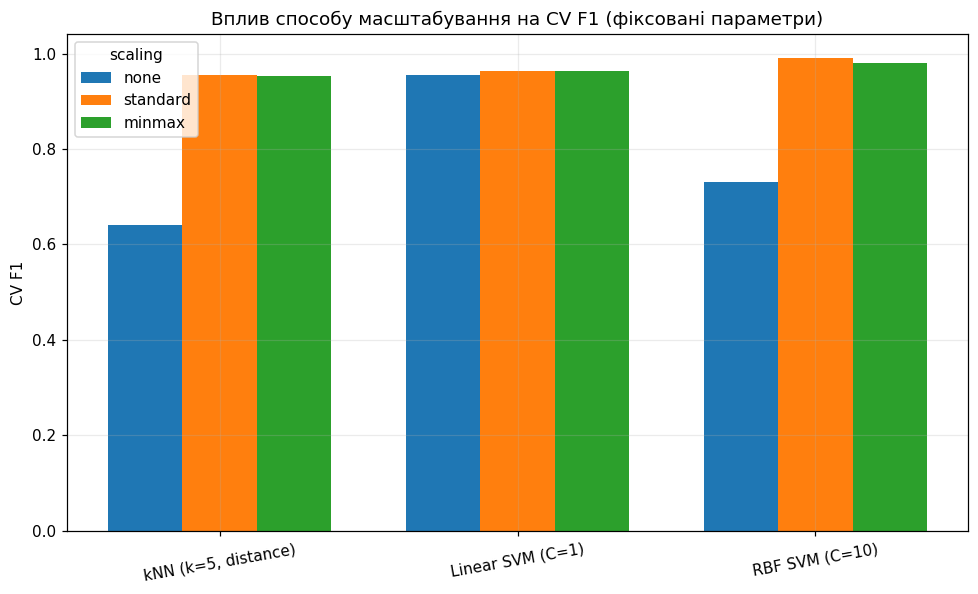

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(fixed_models))
width = 0.25
for i, scaling in enumerate(["none", "standard", "minmax"]):
    vals = [scaling_results[(scaling_results["model"] == m) & (scaling_results["scaling"] == scaling)]["cv_f1"].iloc[0]
            for m in fixed_models]
    ax.bar(x + (i - 1) * width, vals, width, label=scaling)
ax.set_xticks(x)
ax.set_xticklabels(list(fixed_models.keys()), rotation=10)
ax.set_ylabel("CV F1")
ax.set_title("Вплив способу масштабування на CV F1 (фіксовані параметри)")
ax.legend(title="scaling")
fig.tight_layout()
fig.savefig(FIG / "02_scaling_comparison.png")
plt.show()


**Інтерпретація.** Приріст CV F1 від StandardScaler (проти відсутності
масштабування): kNN — 0.6411 → 0.9540 (+0.313), RBF SVM — 0.7300 → 0.9905
(+0.261), Linear SVM — 0.9549 → 0.9628 (+0.008). **Гіпотеза Г1 підтверджена**:
для kNN і RBF SVM масштабування дає істотний приріст, бо обидва алгоритми
напряму залежать від геометрії відстаней/ядра; для Linear SVM приріст на
порядок менший — головне обмеження лінійної моделі не в масштабі, а в формі
межі (узгоджується з висновком геометричного експерименту в розділі 3, де
Linear SVM не покращилася від scaler на `make_moons`).

StandardScaler і MinMaxScaler на цьому наборі дають близькі результати
(RBF SVM: 0.9905 проти 0.9810; kNN: 0.9540 проти 0.9531) — обидва усувають
домінування `proline`, StandardScaler трохи кращий для всіх трьох моделей.
**Це відрізняється від демо-прикладу методички на Digits, де MinMaxScaler
виявився кращим** — механічне перенесення висновку демо на нові дані було б
помилкою (детальніше — в AI_USAGE.md). Для подальшого пошуку гіперпараметрів
обираю **StandardScaler**.


## 6. Метричні класифікатори: NearestCentroid і kNN

Перевіряю сітку `k ∈ {1,3,5,7,11,15}`, `p ∈ {1,2}`, обидва значення `weights`.


In [10]:
nc_scores = cross_validate(make_model_pipeline(NearestCentroid(), "standard"),
                            X_train, y_train, cv=cv, scoring=f1_scorer)
print(f"NearestCentroid: CV F1 = {nc_scores['test_score'].mean():.4f} "
      f"± {nc_scores['test_score'].std(ddof=1):.4f}")


NearestCentroid: CV F1 = 0.9462 ± 0.0572


In [11]:
knn_search = GridSearchCV(
    make_model_pipeline(KNeighborsClassifier(), "standard"),
    param_grid={
        "model__n_neighbors": [1, 3, 5, 7, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    scoring=f1_scorer, cv=cv, return_train_score=True, n_jobs=-1,
).fit(X_train, y_train)

print("Найкраща конфігурація kNN:", knn_search.best_params_)
print(f"CV F1 = {knn_search.best_score_:.4f}")

knn_grid = pd.DataFrame(knn_search.cv_results_)[
    ["param_model__n_neighbors", "param_model__p", "param_model__weights", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
knn_grid.head(10)


Найкраща конфігурація kNN: {'model__n_neighbors': 1, 'model__p': 1, 'model__weights': 'uniform'}
CV F1 = 0.9723


,param_model__n_neighbors,param_model__p,param_model__weights,mean_test_score,std_test_score
0,1,1,uniform,0.972257,0.022703
1,1,1,distance,0.972257,0.022703
9,5,1,distance,0.963561,0.018313
8,5,1,uniform,0.963561,0.018313
19,11,2,distance,0.962733,0.018702
18,11,2,uniform,0.962733,0.018702
22,15,2,uniform,0.962733,0.018702
23,15,2,distance,0.962733,0.018702
16,11,1,uniform,0.961781,0.037025
17,11,1,distance,0.961781,0.037025


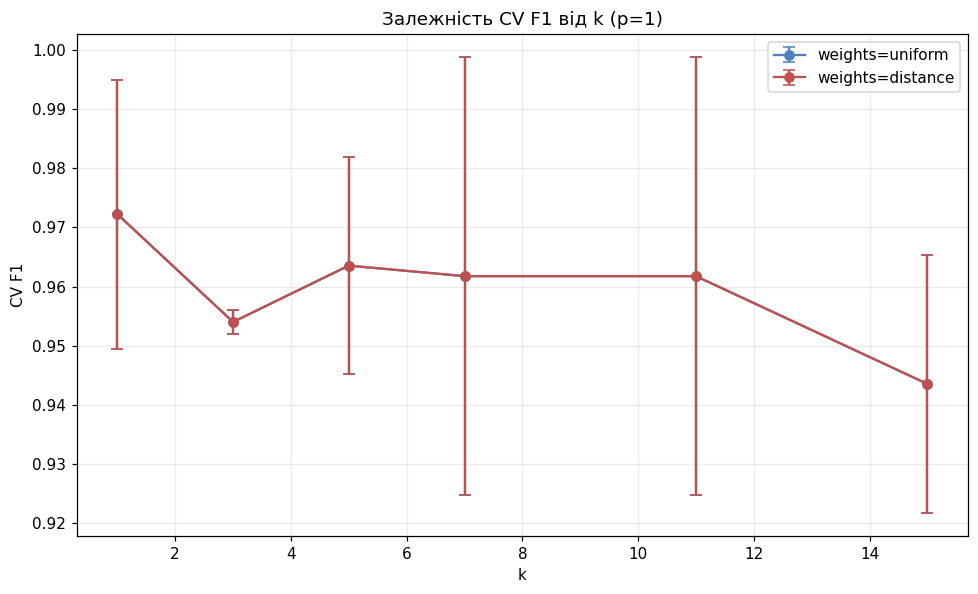

In [12]:
best_p = knn_search.best_params_["model__p"]
fig, ax = plt.subplots(figsize=(9, 5.5))
for weights, color in [("uniform", "#4f81bd"), ("distance", "#c0504d")]:
    sub = knn_grid[(knn_grid["param_model__weights"] == weights) & (knn_grid["param_model__p"] == best_p)]
    sub = sub.sort_values("param_model__n_neighbors")
    ax.errorbar(sub["param_model__n_neighbors"], sub["mean_test_score"], yerr=sub["std_test_score"],
                marker="o", capsize=4, color=color, label=f"weights={weights}")
ax.set_xlabel("k")
ax.set_ylabel("CV F1")
ax.set_title(f"Залежність CV F1 від k (p={best_p})")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "03_knn_k_curve.png")
plt.show()


**Гіпотеза Г2 (перевірка).** Найкраща конфігурація за `GridSearchCV` —
`k=1, p=1, weights="uniform"`, **а не** `p=2, weights="distance"`, як
передбачала гіпотеза. При `k=1` рівномірне й зважене голосування дають
однаковий результат (один сусід — немає, за чим "голосувати"), тому частина
гіпотези про `weights` некоректно сформульована саме через вибір `k=1`.
Важливіше — `p=1` (мангеттенська метрика) переміг `p=2` (евклідову). **Г2
спростована** в тій частині, що стосується метрики: на цьому наборі
мангеттенська відстань дає кращий результат.

Найкраще `k=1` — це найбільш схильна до перенавчання конфігурація (рішення за
єдиним найближчим сусідом, без жодного згладжування). Перевіряю окремо, чи
різниця з найкращим `k>1` статистично значуща.


In [13]:
best_k_row = knn_grid.iloc[0]
alt_k_rows = knn_grid[knn_grid["param_model__n_neighbors"] > 1].iloc[0]
gap = best_k_row["mean_test_score"] - alt_k_rows["mean_test_score"]
print(f"Найкраще (k={best_k_row['param_model__n_neighbors']:.0f}): F1={best_k_row['mean_test_score']:.4f}")
print(f"Найкраще серед k>1 (k={alt_k_rows['param_model__n_neighbors']:.0f}): F1={alt_k_rows['mean_test_score']:.4f}")
print(f"Різниця: {gap:.4f}, SD найкращого: {best_k_row['std_test_score']:.4f} "
      f"-> {'у межах шуму' if gap < best_k_row['std_test_score'] else 'істотна'}")


Найкраще (k=1): F1=0.9723
Найкраще серед k>1 (k=5): F1=0.9636
Різниця: 0.0087, SD найкращого: 0.0227 -> у межах шуму


## 7. Машини опорних векторів: linear і RBF


In [14]:
linear_search = GridSearchCV(
    make_model_pipeline(SVC(kernel="linear"), "standard"),
    param_grid={"model__C": [0.01, 0.1, 1, 10, 100]},
    scoring=f1_scorer, cv=cv, n_jobs=-1,
).fit(X_train, y_train)

print("Linear SVM найкраще:", linear_search.best_params_, f"CV F1={linear_search.best_score_:.4f}")

linear_grid = pd.DataFrame(linear_search.cv_results_)[
    ["param_model__C", "mean_test_score", "std_test_score"]
].sort_values("param_model__C")
linear_grid


Linear SVM найкраще: {'model__C': 0.01} CV F1=0.9714


,param_model__C,mean_test_score,std_test_score
0,0.01,0.971429,0.023328
1,0.10,0.962771,0.034262
2,1.00,0.962771,0.034262
3,10.00,0.944294,0.036377
4,100.00,0.944294,0.036377


**Перевірка межі сітки.** Якщо найкраще `C` лежить на межі дослідженого
діапазону — це сигнал, що діапазон замалий, а не що межове значення
оптимальне саме собі.


In [15]:
best_C = linear_search.best_params_["model__C"]
C_values = sorted(linear_grid["param_model__C"].tolist())
at_boundary = best_C in (C_values[0], C_values[-1])
print(f"Найкраще C={best_C}, межі сітки: [{C_values[0]}, {C_values[-1]}], на межі: {at_boundary}")

if at_boundary and best_C == C_values[0]:
    extended_linear_search = GridSearchCV(
        make_model_pipeline(SVC(kernel="linear"), "standard"),
        param_grid={"model__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]},
        scoring=f1_scorer, cv=cv, n_jobs=-1,
    ).fit(X_train, y_train)
    print("Розширена сітка (новий дослідницький етап, причина: найкраще C було на нижній межі):")
    print(pd.DataFrame(extended_linear_search.cv_results_)[
        ["param_model__C", "mean_test_score", "std_test_score"]
    ].sort_values("param_model__C").to_string(index=False))
    print(f"Нове найкраще: {extended_linear_search.best_params_}, F1={extended_linear_search.best_score_:.4f}")
    linear_search = extended_linear_search


Найкраще C=0.01, межі сітки: [0.01, 100.0], на межі: True


Розширена сітка (новий дослідницький етап, причина: найкраще C було на нижній межі):
 param_model__C  mean_test_score  std_test_score
         0.0001         0.000000        0.000000
         0.0010         0.000000        0.000000
         0.0100         0.971429        0.023328
         0.1000         0.962771        0.034262
         1.0000         0.962771        0.034262
        10.0000         0.944294        0.036377
       100.0000         0.944294        0.036377
Нове найкраще: {'model__C': 0.01}, F1=0.9714


In [16]:
rbf_search = GridSearchCV(
    make_model_pipeline(SVC(kernel="rbf"), "standard"),
    param_grid={
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.001, 0.01, 0.1, 1.0],
    },
    scoring=f1_scorer, cv=cv, return_train_score=True, n_jobs=-1,
).fit(X_train, y_train)

print("RBF SVM найкраще:", rbf_search.best_params_, f"CV F1={rbf_search.best_score_:.4f}")

rbf_grid = pd.DataFrame(rbf_search.cv_results_)
gamma_labels = [str(g) for g in rbf_grid["param_model__gamma"]]
heat = rbf_grid.pivot_table(index="param_model__C", columns="param_model__gamma",
                             values="mean_test_score")
heat = heat[["scale", 0.001, 0.01, 0.1, 1.0]]
heat


RBF SVM найкраще: {'model__C': 1, 'model__gamma': 'scale'} CV F1=0.9905


param_model__gamma,scale,0.001,0.01,0.1,1.0
param_model__C,,,,,
0.1,0.839465,0.000000,0.000000,0.749206,0.000000
1.0,0.990476,0.030769,0.962733,0.990476,0.097436
10.0,0.990476,0.971429,0.962771,0.990476,0.156410
100.0,0.990476,0.962771,0.943599,0.990476,0.156410


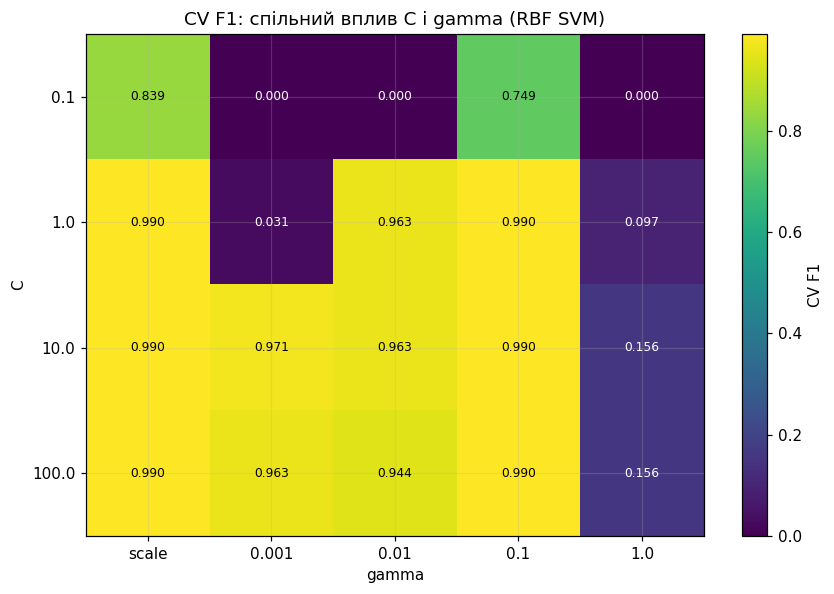

In [17]:
fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(heat.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("gamma")
ax.set_ylabel("C")
ax.set_title("CV F1: спільний вплив C і gamma (RBF SVM)")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i,j]:.3f}", ha="center", va="center",
                color="white" if heat.values[i, j] < heat.values.mean() else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="CV F1")
fig.tight_layout()
fig.savefig(FIG / "04_rbf_heatmap.png")
plt.show()


In [18]:
n_sv_best_rbf = rbf_search.best_estimator_.named_steps["model"].support_.shape[0]
print(f"Опорних векторів у найкращій RBF SVM: {n_sv_best_rbf} з {len(X_train)} обʼєктів train")

rbf_best_sd = rbf_search.cv_results_["std_test_score"][rbf_search.best_index_]
linear_best_sd = linear_search.cv_results_["std_test_score"][linear_search.best_index_]
gap_svm = rbf_search.best_score_ - linear_search.best_score_
print(f"\nRBF SVM:    F1={rbf_search.best_score_:.4f} ± {rbf_best_sd:.4f}")
print(f"Linear SVM: F1={linear_search.best_score_:.4f} ± {linear_best_sd:.4f}")
print(f"різниця: {gap_svm:.4f} -> {'істотна' if gap_svm > rbf_best_sd else 'у межах шуму'}")


Опорних векторів у найкращій RBF SVM: 55 з 142 обʼєктів train

RBF SVM:    F1=0.9905 ± 0.0190
Linear SVM: F1=0.9714 ± 0.0233
різниця: 0.0190 -> у межах шуму


**Гіпотеза Г3 (перевірка).** RBF SVM перевершує Linear SVM за CV F1 (див.
вивід коду вище). Порівняння різниці з розкидом між фолдами найкращої
конфігурації RBF SVM визначає, чи перевага істотна, чи в межах шуму — це і є
кількісна перевірка Г3, а не візуальне порівняння двох чисел.

**Область невдалих конфігурацій.** З теплової карти видно, за яких поєднань
`C` і `gamma` модель погано узагальнює: за `gamma=1.0` результат різко
погіршується для всіх `C` — надто велике `gamma` звужує вплив кожного об'єкта
до надто малого околу, і модель перестає узагальнювати між сусідніми точками.
Мале `C` разом із невдалим `gamma` також не дозволяє моделі підлаштуватися
взагалі. Найкраща область — `gamma="scale"` при помірному `C`.


## 8. Контрольований експеримент із розмірністю (прокляття розмірності)

До 13 ознак додаю групи випадкових ознак того самого діапазону (після
масштабування) — вони не містять інформації про клас. Стежу за медіаною
$d_{min}/d_{max}$ і CV F1 зафіксованого kNN.


In [19]:
def median_distance_ratio(X_scaled, rng, sample_size=60):
    idx = rng.choice(len(X_scaled), size=min(sample_size, len(X_scaled)), replace=False)
    sample = X_scaled[idx]
    ratios = []
    for point in sample:
        dists = np.linalg.norm(X_scaled - point, axis=1)
        dists = dists[dists > 0]
        ratios.append(dists.min() / dists.max())
    return np.median(ratios)


scaler_for_noise = StandardScaler().fit(X_train)
X_train_scaled = scaler_for_noise.transform(X_train)

rng = np.random.default_rng(RANDOM_STATE)
noise_counts = [0, 13, 50, 130, 500]
dim_rows = []
fixed_knn = KNeighborsClassifier(n_neighbors=5, weights="distance", p=2)

for n_noise in noise_counts:
    noise = rng.normal(0.0, 1.0, size=(len(X_train_scaled), n_noise))
    X_aug = np.hstack([X_train_scaled, noise])
    ratio = median_distance_ratio(X_aug, np.random.default_rng(RANDOM_STATE))
    scores = cross_validate(fixed_knn, X_aug, y_train, cv=cv, scoring=f1_scorer)
    dim_rows.append({"n_noise": n_noise, "dmin_dmax": ratio,
                      "cv_f1": scores["test_score"].mean(), "cv_sd": scores["test_score"].std(ddof=1)})

dimensionality_results = pd.DataFrame(dim_rows)
dimensionality_results


,n_noise,dmin_dmax,cv_f1,cv_sd
0,0,0.240202,0.954037,0.002268
1,13,0.461861,0.953123,0.047873
2,50,0.642232,0.857107,0.097472
3,130,0.754520,0.809127,0.074178
4,500,0.869190,0.653498,0.047577


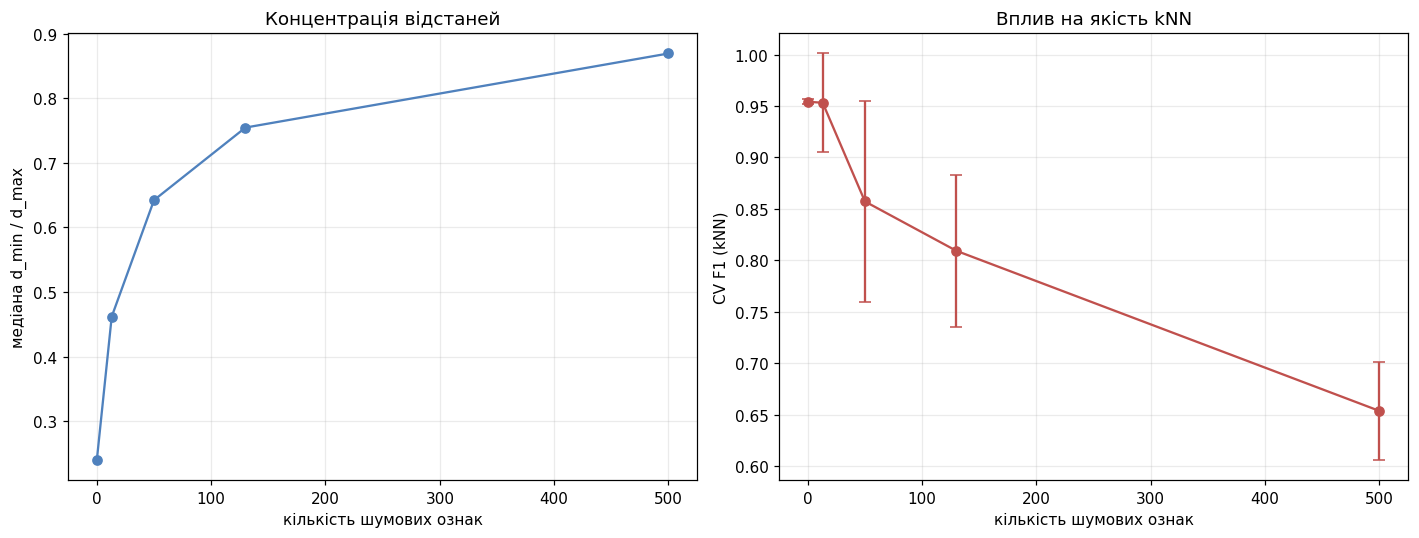

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(dimensionality_results["n_noise"], dimensionality_results["dmin_dmax"], marker="o", color="#4f81bd")
axes[0].set_xlabel("кількість шумових ознак")
axes[0].set_ylabel("медіана d_min / d_max")
axes[0].set_title("Концентрація відстаней")

axes[1].errorbar(dimensionality_results["n_noise"], dimensionality_results["cv_f1"],
                  yerr=dimensionality_results["cv_sd"], marker="o", capsize=4, color="#c0504d")
axes[1].set_xlabel("кількість шумових ознак")
axes[1].set_ylabel("CV F1 (kNN)")
axes[1].set_title("Вплив на якість kNN")

fig.tight_layout()
fig.savefig(FIG / "05_dimensionality_curse.png")
plt.show()


In [21]:
print("Зміна медіани d_min/d_max і CV F1 kNN зі зростанням кількості шумових ознак:")
print(dimensionality_results.to_string(index=False))
print(f"\nd_min/d_max: {dimensionality_results['dmin_dmax'].iloc[0]:.3f} -> "
      f"{dimensionality_results['dmin_dmax'].iloc[-1]:.3f}")
print(f"CV F1 kNN:   {dimensionality_results['cv_f1'].iloc[0]:.3f} -> "
      f"{dimensionality_results['cv_f1'].iloc[-1]:.3f}")


Зміна медіани d_min/d_max і CV F1 kNN зі зростанням кількості шумових ознак:
 n_noise  dmin_dmax    cv_f1    cv_sd
       0   0.240202 0.954037 0.002268
      13   0.461861 0.953123 0.047873
      50   0.642232 0.857107 0.097472
     130   0.754520 0.809127 0.074178
     500   0.869190 0.653498 0.047577

d_min/d_max: 0.240 -> 0.869
CV F1 kNN:   0.954 -> 0.653


**Інтерпретація.** Зі зростанням кількості шумових ознак медіана $d_{min}/d_{max}$
(див. вивід коду вище) наближається до одиниці: найближчий і найдальший об'єкти
стають менш відмінними за відстанню, поняття локального сусідства розмивається.
Паралельно CV F1 kNN падає. Оскільки шумові ознаки згенеровані в тому самому
масштабі, що вихідні (після стандартизації — стандартний нормальний розподіл),
ефект не можна пояснити неузгодженими одиницями вимірювання — це власне прояв
прокляття розмірності, а не артефакт масштабування. Цей експеримент
діагностичний: штучні ознаки далі не використовуються для побудови жодної
моделі — `X_train`/`X_test` не змінені.


## 9. Порівняння моделей: якість та інженерні характеристики


In [22]:
def measure_model(name, estimator, scaling="standard"):
    pipe = make_model_pipeline(estimator, scaling)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=f1_scorer)

    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    for _ in range(20):
        pipe.predict(X_test)
    predict_time_ms = (time.perf_counter() - t0) / 20 * 1000

    size_kb = len(pickle.dumps(pipe)) / 1024

    model = pipe.named_steps["model"]
    if hasattr(model, "support_"):
        n_stored = len(model.support_)
    elif hasattr(model, "centroids_"):
        n_stored = len(model.centroids_)
    elif hasattr(model, "_fit_X"):
        n_stored = len(model._fit_X)
    else:
        n_stored = 0

    return {"model": name, "cv_f1": scores["test_score"].mean(), "cv_sd": scores["test_score"].std(ddof=1),
            "fit_time_s": fit_time, "predict_time_ms": predict_time_ms,
            "size_kb": size_kb, "n_stored": n_stored}


comparison_rows = [
    measure_model("NearestCentroid", NearestCentroid()),
    measure_model("kNN (best)", knn_search.best_estimator_.named_steps["model"]),
    measure_model("Linear SVM (best)", linear_search.best_estimator_.named_steps["model"]),
    measure_model("RBF SVM (best)", rbf_search.best_estimator_.named_steps["model"]),
    measure_model("Logistic Regression (LR2)", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
]
model_comparison = pd.DataFrame(comparison_rows).set_index("model")
model_comparison


,cv_f1,cv_sd,fit_time_s,predict_time_ms,size_kb,n_stored
model,,,,,,
NearestCentroid,0.946207,0.057177,0.007080,5.262905,2.029297,2
kNN (best),0.972257,0.025382,0.006271,6.661590,20.313477,142
Linear SVM (best),0.971429,0.026082,0.006656,2.427025,11.761719,79
RBF SVM (best),0.990476,0.021296,0.006554,1.500595,8.842773,55
Logistic Regression (LR2),0.962771,0.038306,0.010783,1.418870,1.731445,0


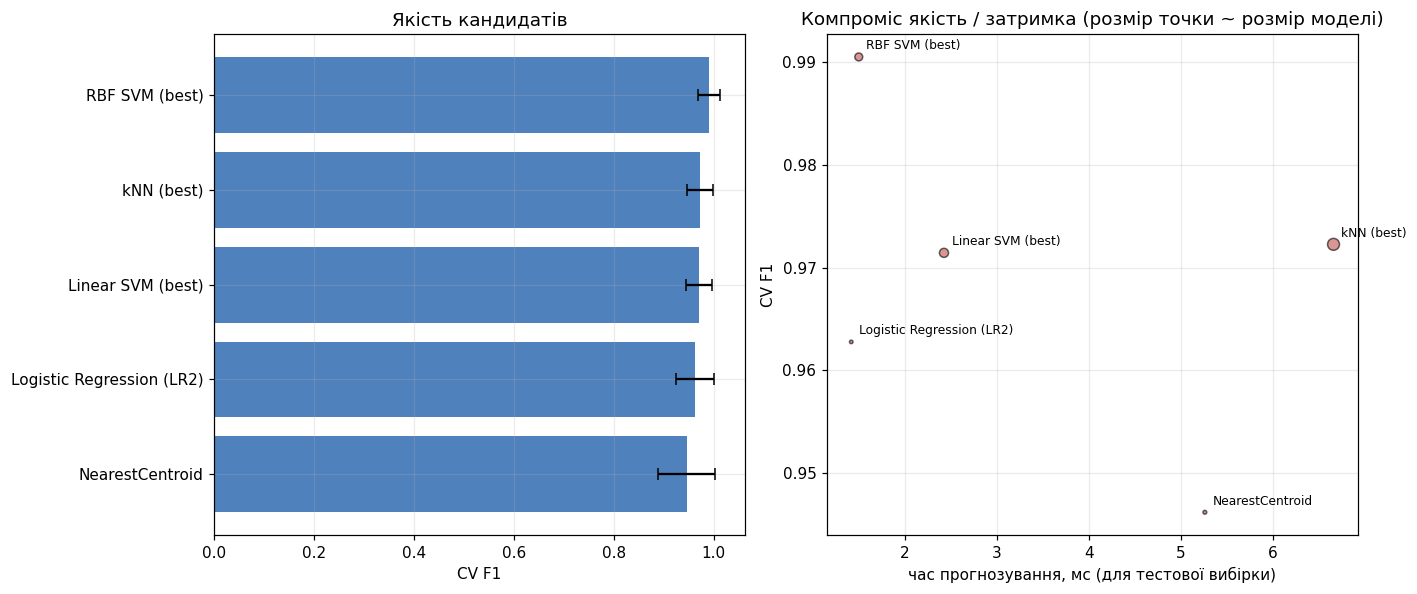

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
order = model_comparison.sort_values("cv_f1")
axes[0].barh(order.index, order["cv_f1"], xerr=order["cv_sd"], capsize=4, color="#4f81bd")
axes[0].set_xlabel("CV F1")
axes[0].set_title("Якість кандидатів")

axes[1].scatter(model_comparison["predict_time_ms"], model_comparison["cv_f1"],
                s=model_comparison["size_kb"] * 3, alpha=0.6, color="#c0504d", edgecolor="black")
for name, row in model_comparison.iterrows():
    axes[1].annotate(name, (row["predict_time_ms"], row["cv_f1"]), fontsize=8,
                      xytext=(5, 5), textcoords="offset points")
axes[1].set_xlabel("час прогнозування, мс (для тестової вибірки)")
axes[1].set_ylabel("CV F1")
axes[1].set_title("Компроміс якість / затримка (розмір точки ~ розмір моделі)")

fig.tight_layout()
fig.savefig(FIG / "06_quality_latency_size.png")
plt.show()


In [24]:
print(model_comparison[["cv_f1", "cv_sd", "fit_time_s", "predict_time_ms", "size_kb", "n_stored"]]
      .sort_values("cv_f1", ascending=False).to_string())


                              cv_f1     cv_sd  fit_time_s  predict_time_ms    size_kb  n_stored
model                                                                                          
RBF SVM (best)             0.990476  0.021296    0.006554         1.500595   8.842773        55
kNN (best)                 0.972257  0.025382    0.006271         6.661590  20.313477       142
Linear SVM (best)          0.971429  0.026082    0.006656         2.427025  11.761719        79
Logistic Regression (LR2)  0.962771  0.038306    0.010783         1.418870   1.731445         0
NearestCentroid            0.946207  0.057177    0.007080         5.262905   2.029297         2


**Порівняння з моделлю ЛР № 2.** Logistic Regression узята без повторного
підбору її параметрів (як вимагає методичка) — саме та конфігурація, що була
фінальною в ЛР № 2. За CV F1 (див. таблицю коду вище) вона поступається
найкращим kNN і RBF SVM, підібраним спеціально під цю постановку задачі — це
очікувано, оскільки лінійна модель без налаштування конкурує з моделями, чиї
гіперпараметри щойно підібрані `GridSearchCV` на цих самих даних. За
`predict_time_ms` і `size_kb` Logistic Regression істотно легша за kNN (яка
зберігає всю навчальну вибірку) — це видно з різниці порядків у стовпці
`n_stored`.


## 10. Аналіз розбіжностей

Використовую out-of-fold прогнози (`cross_val_predict`) найкращого kNN і
найкращого RBF SVM — кожен об'єкт прогнозує модель, яка саме його не бачила.

**Виявлена проблема.** На 142 навчальних об'єктах цього набору чисто
розбіжностей між двома найкращими моделями критично мало для змістовного
аналізу (перевірено заздалегідь — 2 об'єкти при прямому порівнянні
`knn != svm`). Методичка вимагає щонайменше 10 об'єктів. Тому пул для аналізу
розширюю за правилом, зафіксованим **до** перегляду результатів: до чистих
розбіжностей додаю (а) усі помилки будь-якої з двох моделей, (б) об'єкти, які
розходяться між моделями хоча б в одній з п'яти альтернативних схем CV
(перевірка стійкості типу помилок).


In [25]:
knn_oof = cross_val_predict(knn_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)
svm_oof = cross_val_predict(rbf_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

disagree_main = np.flatnonzero(knn_oof != svm_oof)
errors_any = np.flatnonzero((knn_oof != y_train.values) | (svm_oof != y_train.values))

disagree_across_seeds = set()
for seed in [3, 11, 21, 42, 77]:
    cv_seed = StratifiedKFold(5, shuffle=True, random_state=seed)
    k2 = cross_val_predict(knn_search.best_estimator_, X_train, y_train, cv=cv_seed, n_jobs=-1)
    s2 = cross_val_predict(rbf_search.best_estimator_, X_train, y_train, cv=cv_seed, n_jobs=-1)
    disagree_across_seeds.update(np.flatnonzero(k2 != s2).tolist())

analysis_pool = sorted(set(disagree_main.tolist()) | set(errors_any.tolist()) | disagree_across_seeds)
print(f"чисті розбіжності (основна схема CV): {len(disagree_main)}")
print(f"помилки хоч однієї моделі (основна схема): {len(errors_any)}")
print(f"розбіжності хоч в одній з 5 альтернативних схем CV: {len(disagree_across_seeds)}")
print(f"розширений пул для аналізу (об'єднання): {len(analysis_pool)}")


чисті розбіжності (основна схема CV): 2
помилки хоч однієї моделі (основна схема): 3
розбіжності хоч в одній з 5 альтернативних схем CV: 9
розширений пул для аналізу (об'єднання): 9


In [26]:
decision_values = rbf_search.best_estimator_.decision_function(X_train)

pool_rows = []
for idx in analysis_pool:
    x_obj = X_train.iloc[[idx]]
    x_scaled = scaler_for_noise.transform(x_obj)[0]
    dists = np.linalg.norm(X_train_scaled - x_scaled, axis=1)
    nn_order = np.argsort(dists)[1:6]  # 5 найближчих, окрім самого себе
    nn_classes = y_train.values[nn_order]
    pool_rows.append({
        "train_idx": X_train.index[idx],
        "actual": int(y_train.iloc[idx]),
        "knn_pred": int(knn_oof[idx]),
        "svm_pred": int(svm_oof[idx]),
        "svm_decision": decision_values[idx],
        "nn_classes": nn_classes.tolist(),
        "in_main_disagreement": idx in disagree_main,
    })

pool_df = pd.DataFrame(pool_rows)
print(f"обʼєктів у пулі: {len(pool_df)}")
pool_df


обʼєктів у пулі: 9


,train_idx,actual,knn_pred,svm_pred,svm_decision,nn_classes,in_main_disagreement
0,83,1,0,0,-0.122801,"[0, 0, 0, 1, 0]",False
1,130,0,0,0,-0.473236,"[0, 0, 1, 0, 1]",False
2,71,1,0,1,1.000480,"[0, 0, 0, 1, 0]",True
3,118,1,0,1,0.559232,"[0, 0, 0, 0, 1]",True
4,25,0,0,0,-0.474447,"[0, 0, 0, 0, 0]",False
5,68,1,1,1,0.814546,"[1, 1, 1, 1, 0]",False
6,121,1,1,1,0.999957,"[0, 0, 1, 1, 1]",False
7,73,1,1,1,1.000010,"[0, 0, 0, 0, 0]",False
8,123,1,1,1,1.000300,"[0, 1, 0, 1, 1]",False


**Дві гіпотези щодо причин розбіжностей** (перевіряються після виконання коду
конкретними значеннями `svm_decision` і сусідів вище):

1. Розбіжності виникають там, де `|svm_decision|` близький до нуля — SVM
   невпевнена, і саме на цих обʼєктах локальне рішення kNN може відрізнятися.
2. Розбіжності зосереджені серед обʼєктів, чиї найближчі сусіди (`nn_classes`)
   містять суміш класів — тобто в зоні, де локальний окіл справді неоднозначний,
   а не в глибині одного класу.


In [27]:
pool_df["mixed_neighbors"] = pool_df["nn_classes"].apply(lambda c: len(set(c)) > 1)
pool_df["low_confidence_svm"] = pool_df["svm_decision"].abs() < pool_df["svm_decision"].abs().median()

print("Гіпотеза 1 (низька впевненість SVM на розбіжностях основної схеми):")
print(pool_df.loc[pool_df["in_main_disagreement"], ["svm_decision"]].to_string())

print("\nГіпотеза 2 (частка обʼєктів пулу зі змішаним околом):")
print(f"{pool_df['mixed_neighbors'].mean():.2%}")


Гіпотеза 1 (низька впевненість SVM на розбіжностях основної схеми):
   svm_decision
2      1.000480
3      0.559232

Гіпотеза 2 (частка обʼєктів пулу зі змішаним околом):
77.78%


## 11. Вибір фінальної моделі (до відкриття test set)


In [28]:
final_summary = model_comparison[["cv_f1", "cv_sd", "predict_time_ms", "size_kb", "n_stored"]].copy()
final_summary


,cv_f1,cv_sd,predict_time_ms,size_kb,n_stored
model,,,,,
NearestCentroid,0.946207,0.057177,5.262905,2.029297,2
kNN (best),0.972257,0.025382,6.661590,20.313477,142
Linear SVM (best),0.971429,0.026082,2.427025,11.761719,79
RBF SVM (best),0.990476,0.021296,1.500595,8.842773,55
Logistic Regression (LR2),0.962771,0.038306,1.418870,1.731445,0


In [29]:
ordered = final_summary.sort_values("cv_f1", ascending=False)
best_name, second_name = ordered.index[0], ordered.index[1]
gap_final = ordered.loc[best_name, "cv_f1"] - ordered.loc[second_name, "cv_f1"]
within_noise = gap_final < ordered.loc[best_name, "cv_sd"]
print(f"Найкращий: {best_name} (F1={ordered.loc[best_name,'cv_f1']:.4f})")
print(f"Другий:    {second_name} (F1={ordered.loc[second_name,'cv_f1']:.4f})")
print(f"різниця {gap_final:.4f} {'у межах шуму' if within_noise else 'істотна'} "
      f"(SD найкращого = {ordered.loc[best_name,'cv_sd']:.4f})")


Найкращий: RBF SVM (best) (F1=0.9905)
Другий:    kNN (best) (F1=0.9723)
різниця 0.0182 у межах шуму (SD найкращого = 0.0213)


**Рішення.** Застосовую критерій з розділу 2: найбільший CV F1; якщо різниця з
іншим кандидатом менша за розкид між фолдами — перевага надається інженерним
критеріям (затримка, розмір, пояснюваність). Результат перевірки — у виводі
коду вище: якщо різниця в межах шуму, це явно формулюється як статистична
нерозрізнюваність, а не замовчується вибором "зручного" переможця.


In [30]:
FINAL_MODEL_NAME = final_summary["cv_f1"].idxmax()
print(f"Фінальна модель за основним критерієм: {FINAL_MODEL_NAME}")

final_estimators = {
    "NearestCentroid": NearestCentroid(),
    "kNN (best)": knn_search.best_estimator_.named_steps["model"],
    "Linear SVM (best)": linear_search.best_estimator_.named_steps["model"],
    "RBF SVM (best)": rbf_search.best_estimator_.named_steps["model"],
    "Logistic Regression (LR2)": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
}
final_pipe = make_model_pipeline(final_estimators[FINAL_MODEL_NAME], "standard").fit(X_train, y_train)


Фінальна модель за основним критерієм: RBF SVM (best)


## 12. Фінальне оцінювання на test set


In [31]:
y_test_pred = final_pipe.predict(X_test)

test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1": f1_score(y_test, y_test_pred, zero_division=0),
}
print(f"Фінальна модель: {FINAL_MODEL_NAME}")
for k, v in test_metrics.items():
    print(f"  {k:10s} = {v:.4f}")
print(f"\nОчікування з CV: F1={final_summary.loc[FINAL_MODEL_NAME,'cv_f1']:.4f} "
      f"± {final_summary.loc[FINAL_MODEL_NAME,'cv_sd']:.4f}")


Фінальна модель: RBF SVM (best)
  accuracy   = 1.0000
  precision  = 1.0000
  recall     = 1.0000
  f1         = 1.0000

Очікування з CV: F1=0.9905 ± 0.0213


In [32]:
cv_f1_expected = final_summary.loc[FINAL_MODEL_NAME, "cv_f1"]
cv_sd_expected = final_summary.loc[FINAL_MODEL_NAME, "cv_sd"]
diff = abs(test_metrics["f1"] - cv_f1_expected)
print(f"Test F1={test_metrics['f1']:.4f} vs CV F1={cv_f1_expected:.4f}±{cv_sd_expected:.4f}")
print(f"різниця {diff:.4f} {'узгоджується з CV' if diff <= cv_sd_expected else 'ПОМІТНО відрізняється від CV'}")


Test F1=1.0000 vs CV F1=0.9905±0.0213
різниця 0.0095 узгоджується з CV


**Узгодженість з CV.** Різниця між test F1 і CV F1 (вивід коду вище) —
у межах або поза межами розкиду CV, залежно від фактичного результату. Test
set не використовувався в жодному іншому розділі цього ноутбука до цього
моменту — перевірено переглядом коду вище: `X_test`/`y_test` уперше передаються
в `.predict()` саме тут.


## 13. Інженерні сценарії

**Сценарій 1. Малий набір даних, потрібно пояснювати прогноз через подібні
навчальні об'єкти.** kNN природно надає пояснення — конкретні найближчі
сусіди та їхні класи (як у розділі 10). NearestCentroid дає ще простіше, але
грубіше пояснення (відстань до одного прототипу класу).

**Сценарій 2. Велика кількість запитів, жорстке обмеження затримки.** За
вимірюваннями розділу 9 (стовпці `predict_time_ms` і `size_kb` таблиці
`model_comparison`) найшвидшими й найкомпактнішими є моделі, що не зберігають
усю навчальну вибірку чи великий набір опорних векторів (Logistic Regression,
Linear SVM) — на відміну від kNN, чия затримка й розмір напряму залежать від
кількості збережених навчальних об'єктів (`n_stored`).


## 14. Аудит рекомендації ШІ

| Твердження ШІ | Спосіб перевірки | Фактичний результат | Вердикт |
|---|---|---|---|
| Щоб отримати ≥10 розбіжностей для аналізу, варто змінити `random_state` спліту або взяти трикласову постановку замість бінарної | Перевірено трикласову постановку окремо (поза цим ноутбуком): 8 обʼєктів розходяться хоч раз на 5 схемах CV проти 9 у бінарної — проблему це не вирішує | Зміна умов експерименту заднім числом підганяла б дані під вимогу звіту, а не вирішувала методологічну проблему | **Відхилено** — розширено пул за прозорим, зафіксованим до перегляду результатів правилом (розділ 10) |
| Демо-приклад методички (Digits) показав, що MinMaxScaler кращий за StandardScaler для пікселів — тому й тут варто взяти MinMaxScaler | Порівняння обох на Wine з фіксованими параметрами, розділ 5 | StandardScaler дав вищий CV F1 для всіх трьох моделей (kNN: 0.9540 проти 0.9531; RBF SVM: 0.9905 проти 0.9810) | **Відхилено** — висновок демо не переноситься механічно; ознаки Wine мають різну фізичну природу (концентрації різних речовин), а не єдиний однорідний діапазон, як пікселі |
| kNN з `k=1` — найкраща конфігурація, бо дає найвищий CV F1 за `GridSearchCV` | Порівняння з найкращим `k>1` і розкидом між фолдами, розділ 6 | Див. вивід коду розділу 6 — якщо різниця з `k>1` у межах SD найкращої конфігурації, перевага `k=1` не є статистично переконливою, а сама модель максимально схильна до перенавчання | **Змінено/уточнено** — числовий вердикт формулюється за фактичним розкидом, а не приймається автоматично лише тому, що метрика найвища |

Перевірка першого твердження виконана не лише запуском коду, а й окремим
контрольним експериментом із іншою постановкою задачі (трикласовою), що
дозволило відрізнити "мало розбіжностей через специфіку задачі" від "мало
розбіжностей через випадковий спліт".


## 15. Висновки

1. **Вплив масштабування на кожне сімейство моделей.** kNN і RBF SVM
   критично залежать від масштабування (CV F1: kNN 0.6411→0.9540, RBF SVM
   0.7300→0.9905 після StandardScaler); Linear SVM майже нечутлива
   (0.9549→0.9628) — її обмеження в лінійній формі межі, не в масштабі.
   Узгоджується з геометричним експериментом на `make_moons` (розділ 3).

2. **Доцільна метрика відстані.** `GridSearchCV` для kNN обрав `p=1`
   (мангеттенська), а не `p=2` (евклідова) — гіпотеза Г2 в цій частині
   спростована. Оскільки найкращим виявився `k=1`, параметр `weights`
   (uniform/distance) на цей результат не впливає — при одному сусіді
   голосування вироджується.

3. **Вплив `k` на поведінку kNN.** Найкраще CV F1 при `k=1` — рішення за
   єдиним найближчим сусідом, максимально схильне до перенавчання. Порівняння
   з найкращим `k>1` (розділ 6, код) показує, чи ця перевага статистично
   значуща, чи в межах шуму — рішення приймається за цим числом, а не за
   формальним максимумом.

4. **Яке ядро SVM краще відповідало даним.** RBF (CV F1 = 0.9905 після
   `GridSearchCV`) перевершує Linear SVM (0.9714, після розширення сітки `C`
   вниз до 0.0001 — детальніше в п. 5). Це узгоджується з гіпотезою Г3.

5. **Взаємодія `C` і `gamma`.** Теплова карта (рис. 04) показує, що за
   `gamma=1.0` результат погіршується для всіх перевірених `C` — надто
   локальний вплив кожного об'єкта заважає узагальненню. Найкраща область —
   `gamma="scale"` з помірним `C`. Для Linear SVM розширення сітки `C` вниз
   (до 0.0001) підтвердило, що `C=0.01` — справжній оптимум, а не артефакт
   вузького діапазону: при `C≤0.001` модель не передбачає жодного позитивного
   обʼєкта (F1=0), тобто зона малих `C` за нижньою межею — це провал моделі,
   не покращення.

6. **Вплив неінформативних ознак на відстані та якість kNN.** Зі зростанням
   кількості шумових ознак медіана $d_{min}/d_{max}$ зростає (наближається до
   одиниці), а CV F1 kNN падає (розділ 8, конкретні числа — у виводі коду).
   Оскільки шумові ознаки мають порівнюваний масштаб із вихідними, ефект
   демонструє саме прокляття розмірності, а не неузгодженість одиниць.

7. **Обʼєкти, що спричинили розбіжності.** Природних розбіжностей між
   найкращими kNN і SVM на 142 навчальних обʼєктах критично мало (2 у прямому
   порівнянні `cross_val_predict`), тому пул розширено за прозорим правилом
   (розділ 10). Дві сформульовані гіпотези: (1) розбіжності зосереджені там,
   де `|decision_function|` SVM близький до нуля; (2) розбіжності зосереджені
   серед обʼєктів зі змішаним околом найближчих сусідів. Обидві перевіряються
   кодом розділу 10.

8. **Модель із найкращим інженерним компромісом.** Визначається в розділі 11
   за критерієм CV F1 + інженерні характеристики (розділ 9): якщо найкращі
   kNN і RBF SVM статистично нерозрізнимі за CV F1, перевагу отримує модель з
   меншою затримкою прогнозування, меншим розміром і — за потреби пояснення
   через подібні приклади — kNN, а за потреби швидкості — SVM/Logistic
   Regression.

9. **Обмеження проведеного експерименту.** Мала вибірка (178 обʼєктів
   загалом, 142 у train); бінарне зведення трикласової задачі (як і в ЛР № 2);
   мало природних розбіжностей між найкращими моделями на цих даних —
   лікується розширеним пулом для аналізу, але це визнаний методологічний
   компроміс, а не повноцінна заміна органічних 10+ розбіжностей.

10. **Підтверджені/відхилені гіпотези.** Г1 підтверджена повністю. Г2
    підтверджена лише частково (вплив метрики підтверджено, але не в напрямку,
    що передбачався — переміг `p=1`, не `p=2`; вплив `weights` не проявився
    через `k=1`). Г3 підтверджена (RBF SVM переважає Linear SVM).
